# Probabilistic Graph Forecasting with Autoregressive Decoders

This note gives a concise introduction to a temporal latent-variable model for **graph sequences** $\{G_t\}_{t=1}^T$ with $G_t=(X_t,A_t)$. It states the model, the training objective (ELBO) in a time-factorized form, the concrete likelihoods used for node features and edges, the effect of a deterministic decoder, and how to generate future graphs.



## Problem setup

We observe a sequence of graph snapshots

$$
G_t = (X_t, A_t), \quad t=1,\dots,T,
$$

where $X_t \in \mathbb{R}^{n \times d}$ stacks node feature vectors $x_t^v$ and $A_t \in \{0,1\}^{n \times n}$ is an undirected adjacency matrix (no self-loops). To capture temporal structure we introduce a latent trajectory

$$
Z_{0:T} = (Z_0, \dots, Z_T), \quad Z_t \in \mathbb{R}^m,
$$

where $Z_t$ is a global latent representation of the whole graph at time $t$.


## Generative (autoregressive latent) model

An autoregressive factorization is used:

$$
p_\theta(X_{1:T}, A_{1:T}, Z_{0:T})
= p(Z_0) \prod_{t=0}^{T-1} p_\theta(Z_{t+1}\mid Z_t)\; p_\theta(X_{t+1}, A_{t+1}\mid Z_t)
$$

Intuition: the latent $Z_t$ summarizes the state at $t$; a transition model $p_\theta(Z_{t+1}\mid Z_t)$ evolves it; conditioned on the current latent we predict the *next* snapshot $(X_{t+1}, A_{t+1})$.

We approximate the true posterior with an amortized encoder (e.g. a GNN+RNN):

$$
q_\phi(Z_t \mid X_{1:t}, A_{1:t}) \quad \text{(often factorized across $t$ for amortization).}
$$


## Variational lower bound (ELBO) — time decomposition

Using the variational approximation

$$
q_\phi(Z_{1:T}\mid X_{1:T},A_{1:T}) = \prod_{t=1}^T q_\phi(Z_t \mid X_{1:t},A_{1:t}),
$$

the marginal log-likelihood admits the ELBO:

$$
\log p_\theta(X_{1:T}, A_{1:T}) \ge
\mathbb{E}_{q_\phi} \Big[ \sum_{t=1}^{T-1} \log p_\theta(X_{t+1}, A_{t+1} \mid Z_t) \Big]
- \mathrm{KL}\big(q_\phi(Z_1 \mid X_1, A_1) \,\|\, p(Z_1)\big)
- \sum_{t=1}^{T-1} \mathbb{E}_{q_\phi} \Big[ \mathrm{KL}\big(q_\phi(Z_{t+1}\mid X_{1:t+1}, A_{1:t+1}) \,\|\, p_\theta(Z_{t+1}\mid Z_t)\big) \Big].
$$

Thus the objective is a sum over time: per-step reconstruction terms plus per-step KL penalties that align the encoder's posterior with the learned transition prior.



## Explicit reconstruction likelihoods

If the decoder factorizes into Gaussian node-features and Bernoulli edges:

- **Node features (per node $v$)**

$$
p_\theta(x_{t+1}^v \mid Z_t) = \mathcal{N}(x_{t+1}^v \mid \mu_\theta^v(Z_t), \Sigma_\theta^v(Z_t)),
$$

hence the feature log-likelihood (for all nodes) is

$$
\log p_\theta(X_{t+1} \mid Z_t)
= -\frac{1}{2} \sum_{v=1}^n \Big[ (x_{t+1}^v - \mu_\theta^v)^\top (\Sigma_\theta^v)^{-1} (x_{t+1}^v - \mu_\theta^v) + \log \det(2 \pi \Sigma_\theta^v) \Big].
$$

(In practice $\Sigma^v$ is taken diagonal or shared for numerical stability.)

- **Edges (for unordered pairs $u<v$)**

$$
p_\theta(A_{t+1} \mid Z_t) = \prod_{u<v} \mathrm{Bernoulli}\big(A_{t+1}^{uv} \mid \pi_\theta^{uv}(Z_t)\big),
$$

so

$$
\log p_\theta(A_{t+1} \mid Z_t) = \sum_{u<v} \Big[ A_{uv} \log \pi_{uv} + (1-A_{uv}) \log (1-\pi_{uv}) \Big].
$$

Combine them:

$$
\log p_\theta(X_{t+1}, A_{t+1} \mid Z_t) = \log p_\theta(X_{t+1} \mid Z_t) + \log p_\theta(A_{t+1} \mid Z_t).
$$


## Deterministic decoder

If the decoder is deterministic (e.g. $X_{t+1}=f_\theta(Z_t)$, $A_{t+1}=g_\theta(Z_t)$ or equivalently Gaussian with vanishing variance), then:

- The likelihood becomes a Dirac (or degenerate Gaussian); log-likelihood is $-\infty$ off the model manifold — numerically unstable.
- Deterministic decoders cannot model multimodality: a single $Z_t$ maps to a single snapshot, so they fail when the conditional distribution is multi-valued.
- Training tends to overfit (model memorizes) or produce poor uncertainty calibration. Probabilistic decoders (non-zero variance, Bernoulli edges) are preferred for stable likelihood-based training and to capture uncertainty/diversity.


## Generating future graphs

Given observed history $X_{1:T}, A_{1:T}$:

1. Infer the posterior at final time: $q_\phi(Z_T \mid X_{1:T}, A_{1:T})$ and sample $z_T \sim q_\phi$ (or use the posterior mean).
2. For $h=1$ to $H$:
   - Sample latent: $z_{T+h} \sim p_\theta(Z_{T+h} \mid z_{T+h-1})$.
   - Sample (or take mean of) snapshot: $(\tilde X_{T+h}, \tilde A_{T+h}) \sim p_\theta(\cdot \mid z_{T+h-1})$ (or use the decoder mean).





In [2]:
import math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

## 1) Synthetic dynamic graph dataset
**Goal:**  
Create dynamic graphs using SBM with Gaussian node features.

**Hints:**  
- `generate_sbm`: adjacency with `p_in` (intra) and `p_out` (inter) edges.  
- `generate_features`: node features from `N(μ_k, Σ_k)` per community.  
- `generate_sequence`: simulate T timesteps with drift and edge flips.  
- `_getitem_` / `_len_`: return sequences.  
- `collate_fn`: batch multiple sequences.

**Output:**  
- `X_seq`: `[T, n_nodes, feat_dim]`  
- `A_seq`: `[T, n_nodes, n_nodes]`

In [3]:
import scipy.sparse as sp


def generate_sbm(n_nodes: int, n_communities: int, p_in: float, p_out: float):
    """
    Generate a single undirected SBM adjacency matrix (no self-loops).
    Returns dense torch tensor of shape [n_nodes, n_nodes] with 0/1 entries.
    """
    # Fixed community assignment (same for the whole sequence)
    community_size = n_nodes // n_communities
    labels = torch.arange(n_communities).repeat_interleave(community_size)
    if len(labels) < n_nodes:
        labels = torch.cat([labels, torch.zeros(n_nodes - len(labels), dtype=torch.long)])

    row, col = torch.meshgrid(torch.arange(n_nodes), torch.arange(n_nodes), indexing='ij')
    same_comm = labels[row] == labels[col]
    prob = torch.where(same_comm, p_in, p_out).float()

    bern = torch.rand(n_nodes, n_nodes) < prob
    adj = bern.float()
    # undirected → symmetrize + remove self-loops
    adj = (adj + adj.t()) / 2
    adj = adj - torch.diag(torch.diag(adj))
    adj = (adj > 0).float()
    return adj


def generate_features(n_nodes: int, n_communities: int, feat_dim: int, std: float = 0.5):
    """
    Generate node features from per-community Gaussians.
    Returns [n_nodes, feat_dim].
    """
    community_size = n_nodes // n_communities
    labels = torch.arange(n_communities).repeat_interleave(community_size)
    if len(labels) < n_nodes:
        labels = torch.cat([labels, torch.zeros(n_nodes - len(labels), dtype=torch.long)])

    # each community has its own mean (randomly placed on unit sphere + offset)
    means = torch.randn(n_communities, feat_dim)
    means = means / means.norm(dim=1, keepdim=True) * 3.0

    x = means[labels] + torch.randn(n_nodes, feat_dim) * std
    return x


class SyntheticGraphDataset(Dataset):
    """
    Synthetic evolving graph sequences.
    - Fixed community structure (SBM) with slowly drifting p_in / p_out.
    - Node features perform a smooth random walk inside each community.
    - Edges are flipped with probability p_flip each step → smooth changes.
    """
    def __init__(
        self,
        n_nodes: int = 30,
        n_communities: int = 3,
        feat_dim: int = 4,
        T: int = 40,
        n_seq: int = 200,
        p_flip: float = 0.03,
        seed: int = 42
    ):
        super().__init__()
        self.n_nodes = n_nodes
        self.n_communities = n_communities
        self.feat_dim = feat_dim
        self.T = T
        self.n_seq = n_seq
        self.p_flip = p_flip

        self.rng = np.random.default_rng(seed)
        torch.manual_seed(seed)

        # Pre-generate community assignments (same for every sequence)
        community_size = n_nodes // n_communities
        self.labels = torch.arange(n_communities).repeat_interleave(community_size)
        if len(self.labels) < n_nodes:
            extra = n_nodes - len(self.labels)
            self.labels = torch.cat([self.labels, torch.zeros(extra, dtype=torch.long)])

    def generate_sequence(self):
        """
        Generate one sequence of length T.
        Returns:
            X_seq: torch.FloatTensor [T, n_nodes, feat_dim]
            A_seq: torch.FloatTensor [T, n_nodes, n_nodes] (0/1 symmetric)
        """
        # ----- slowly drifting intra / inter probabilities -----
        p_in_base = self.rng.uniform(0.4, 0.8)
        p_out_base = self.rng.uniform(0.01, 0.1)

        p_in_t = p_in_base + 0.15 * torch.sin(torch.linspace(0, 2 * np.pi, self.T + 1)[:-1])
        p_out_t = p_out_base + 0.05 * torch.cos(torch.linspace(0, 2 * np.pi, self.T + 1)[:-1])

        # ----- node features: smooth random walk per community -----
        means = torch.randn(self.n_communities, self.feat_dim)
        means = means / means.norm(dim=1, keepdim=True) * 3.0

        X_seq = torch.zeros(self.T, self.n_nodes, self.feat_dim)
        X_seq[0] = means[self.labels] + torch.randn(self.n_nodes, self.feat_dim) * 0.5

        for t in range(1, self.T):
            # small Gaussian step, stronger inside-community pull
            drift = 0.02 * (means[self.labels] - X_seq[t-1])
            noise = torch.randn_like(X_seq[t-1]) * 0.08
            X_seq[t] = X_seq[t-1] + drift + noise

        # ----- adjacency matrices: start from SBM, then flip edges slowly -----
        A0 = generate_sbm(self.n_nodes, self.n_communities,
                          p_in_t[0].item(), p_out_t[0].item())

        A_seq = torch.zeros(self.T, self.n_nodes, self.n_nodes)
        A_seq[0] = A0

        for t in range(1, self.T):
            # probability matrix for current time step
            same_comm = self.labels[:, None] == self.labels[None, :]
            prob = torch.where(same_comm, p_in_t[t], p_out_t[t])

            # keep existing edges with probability (1 - p_flip), otherwise resample
            keep = torch.rand(self.n_nodes, self.n_nodes) > self.p_flip
            new_edges = torch.rand(self.n_nodes, self.n_nodes) < prob

            A_new = torch.where(keep, A_seq[t-1], new_edges.float())
            # enforce symmetry & no self-loops
            A_new = (A_new + A_new.t()) / 2
            A_new = A_new - torch.diag(torch.diag(A_new))
            A_new = (A_new > 0).float()
            A_seq[t] = A_new

        return X_seq, A_seq

    def __len__(self):
        return self.n_seq

    def __getitem__(self, idx):
        # each call generates a fresh sequence (good for on-the-fly generation)
        X_seq, A_seq = self.generate_sequence()
        return {"X": X_seq, "A": A_seq}


def collate_fn(batch):
    """
    Collate list of sequences into batched tensors.
    Returns:
        X_batch: [B, T, n_nodes, feat_dim]
        A_batch: [B, T, n_nodes, n_nodes]
    """
    X_seqs = [item["X"] for item in batch]
    A_seqs = [item["A"] for item in batch]

    X_batch = torch.stack(X_seqs, dim=0)      # [B, T, n, f]
    A_batch = torch.stack(A_seqs, dim=0)      # [B, T, n, n]
    return {"X": X_batch, "A": A_batch}

## 2) Encoder, Prior, Decoder

### SimpleGraphEncoder
Aggregates node features and degree statistics.  
Computes graph-level latent embeddings `mu` and `logvar` for VAE.  
No external graph libraries required; uses only PyTorch.

### TransitionPrior
Models the latent temporal evolution `p(Z_{t+1} | Z_t)` as a Gaussian.  
Produces mean and variance for autoregressive sampling in VAE.

### Decoder
Reconstructs node features and adjacency matrices from latent `Z_t`.  
Uses node embeddings combined with latent vectors for feature decoding.  
Produces edge logits for Bernoulli reconstruction of adjacency.  
Supports probabilistic reconstruction via Gaussian features + Bernoulli edges.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleGraphEncoder(nn.Module):
    """
    Very simple graph encoder using only degree statistics and mean pooling.
    No torch_geometric required.
    Input:  X [B, n_nodes, feat_dim], A [B, n_nodes, n_nodes]
    Output: mu_z, logvar_z  [B, latent_dim]
    """
    def __init__(self, feat_dim: int, latent_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.feat_dim = feat_dim
        self.latent_dim = latent_dim

        # Node feature MLP
        self.node_mlp = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # Degree encoder (scalar degree → embedding)
        self.degree_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # Final projection to latent statistics
        self.mu_head = nn.Linear(hidden_dim * 2, latent_dim)
        self.logvar_head = nn.Linear(hidden_dim * 2, latent_dim)

    def forward(self, X: torch.Tensor, A: torch.Tensor):
        """
        X: [B, n_nodes, feat_dim]
        A: [B, n_nodes, n_nodes] (0/1 symmetric)
        """
        B, n, _ = X.shape

        # 1. Node embeddings
        h_nodes = self.node_mlp(X)                              # [B, n, h]

        # 2. Degree features
        degrees = A.sum(dim=-1, keepdim=True).float()            # [B, n, 1]
        h_deg = self.degree_mlp(degrees / degrees.max().clamp(min=1.0))  # normalize

        # 3. Global pooling (mean over nodes)
        h_global = torch.cat([
            h_nodes.mean(dim=1),                                 # [B, h]
            h_deg.mean(dim=1)                                    # [B, h]
        ], dim=-1)                                               # [B, 2h]

        # 4. Latent parameters
        mu = self.mu_head(h_global)
        logvar = self.logvar_head(h_global)
        logvar = logvar.clamp(max=10)  # prevent explosion

        return mu, logvar


class TransitionPrior(nn.Module):
    """ p(Z_{t+1} | Z_t) modeled as a Gaussian with MLP """
    def __init__(self, latent_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden_dim, latent_dim)
        self.logvar_head = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z_t: torch.Tensor):
        """
        z_t: [B, latent_dim] or [B, T, latent_dim]
        Returns mu_prior, logvar_prior of the same shape
        """
        h = self.mlp(z_t)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        logvar = logvar.clamp(min=-8, max=5)  # stable variance range
        return mu, logvar


class Decoder(nn.Module):
    """
    Probabilistic decoder:
      - Node features: Gaussian with diagonal covariance (shared variance)
      - Edges: Bernoulli via inner product of learned node embeddings + global latent modulation
    """
    def __init__(self, latent_dim: int, feat_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.latent_dim = latent_dim
        self.feat_dim = feat_dim

        # Global latent → node-level modulation
        self.z_to_node = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # Base node embeddings (learned per node)
        self.node_emb = nn.Parameter(torch.randn(100, hidden_dim))  # max 100 nodes

        # Feature decoder
        self.feat_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feat_dim)
        )

        # Shared logvar for feature noise (learnable scalar per graph)
        self.logvar_feat = nn.Parameter(torch.tensor(0.0))

        # Edge bias from global latent
        self.edge_bias = nn.Linear(latent_dim, 1)

    def forward(self, z: torch.Tensor, n_nodes: int):
        """
        z: [B, latent_dim]          (global latent at time t)
        n_nodes: int                (number of nodes, can vary per graph)
        Returns:
            x_mu:     [B, n_nodes, feat_dim]
            x_logvar: [B, n_nodes, feat_dim]  (shared variance)
            edge_logits: [B, n_nodes, n_nodes]
        """
        B = z.size(0)
        device = z.device

        # Node embeddings (shared across graphs, truncated/padded)
        node_emb = self.node_emb[:n_nodes]                   # [n, h]
        node_emb = node_emb.unsqueeze(0).expand(B, -1, -1)   # [B, n, h]

        # Modulate node embeddings with global latent
        z_mod = self.z_to_node(z).unsqueeze(1)               # [B, 1, h]
        h_nodes = node_emb + z_mod                           # broadcast modulation

        # Decode node features
        x_mu = self.feat_decoder(h_nodes)                    # [B, n, feat_dim]
        x_logvar = self.logvar_feat.expand(B, n_nodes, self.feat_dim)

        # Edge logits: inner product + global bias
        edge_logits = torch.matmul(h_nodes, h_nodes.transpose(-1, -2))  # [B, n, n]
        bias = self.edge_bias(z)                             # [B, 1]
        edge_logits = edge_logits + bias.unsqueeze(-1) + bias.unsqueeze(-2)

        # Zero out diagonal
        edge_logits = edge_logits - 1000.0 * torch.eye(n_nodes, device=device).unsqueeze(0)

        return x_mu, x_logvar, edge_logits

`reparameterize`: samples latent variable using the reparameterization trick.  
`kl_gauss`: closed-form KL divergence between two Gaussians.  
`nll_gaussian`: negative log-likelihood for node features.  
`nll_bernoulli`: negative log-likelihood (binary cross-entropy) for edges.

In [7]:
def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """
    Reparameterization trick: z = mu + std * eps
    Args:
        mu:     [..., latent_dim]
        logvar: [..., latent_dim]
    Returns:
        z:      [..., latent_dim] (sampled latent)
    """
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


def kl_gauss(mu_q: torch.Tensor, logvar_q: torch.Tensor,
             mu_p: torch.Tensor, logvar_p: torch.Tensor) -> torch.Tensor:
    """
    Closed-form KL(q || p) for diagonal Gaussians.
    All inputs: [..., latent_dim]
    Returns KL of the same shape (can be reduced later).
    """
    kl = 0.5 * (logvar_p - logvar_q +
                (torch.exp(logvar_q) + (mu_q - mu_p).pow(2)) / torch.exp(logvar_p) - 1.0)
    return kl.sum(dim=-1)  # sum over latent dimensions


def nll_gaussian(x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """
    Negative log-likelihood of x under diagonal Gaussian N(mu, exp(logvar)).
    x, mu, logvar: [..., n_nodes, feat_dim]
    Returns scalar per graph (already averaged over nodes & features).
    """
    # (B, T, n, f) or (B, n, f) → we sum over all dimensions except batch
    var = torch.exp(logvar)
    nll = 0.5 * (
        torch.log(var) + (x - mu).pow(2) / var + torch.log(torch.tensor(2.0 * torch.pi))
    )
    return nll.sum(dim=[-2, -1])  # sum over nodes and features


def nll_bernoulli(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Binary cross-entropy for undirected edges (upper triangle only to avoid double-counting).
    logits: [..., n_nodes, n_nodes] (raw logits)
    target: [..., n_nodes, n_nodes] (0/1 symmetric float)
    """
    # Use built-in BCE with logits for stability
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')

    # For undirected graphs: mask out diagonal + lower triangle to count each edge once
    n = target.size(-1)
    mask = torch.triu(torch.ones(n, n, device=target.device), diagonal=1)  # [n, n]
    mask = mask.unsqueeze(0).unsqueeze(0)  # broadcast to batch & time

    # Expand mask to full tensor shape
    while mask.dim() < bce.dim():
        mask = mask.unsqueeze(0)

    bce = bce * mask
    return bce.sum(dim=[-2, -1])  # sum over edge dimension

## 4) TemporalGraphVAE
Define the Temporal Graph VAE model.  
- Encode node features & adjacency into latent `z`.  
- Model transitions `p(z_{t+1}|z_t)`.  
- Decode `z` to reconstruct node features and edges.  
- Compute ELBO (reconstruction + KL) for training.

In [20]:
class TemporalGraphVAE(nn.Module):
    def __init__(self, n_nodes=30, feat_dim=4, z_dim=16, hidden_dim=64):
        super().__init__()
        self.n_nodes = n_nodes
        self.feat_dim = feat_dim
        self.z_dim = z_dim

        # p(z_0): standard normal
        self.register_buffer("z0_mu", torch.zeros(z_dim))
        self.register_buffer("z0_logvar", torch.zeros(z_dim))

        self.encoder = SimpleGraphEncoder(feat_dim=feat_dim, latent_dim=z_dim, hidden_dim=hidden_dim)
        self.prior   = TransitionPrior(latent_dim=z_dim, hidden_dim=hidden_dim)
        self.decoder = Decoder(latent_dim=z_dim, feat_dim=feat_dim, hidden_dim=hidden_dim)

    def forward(self, X_seq, A_seq, kl_weight=1.0):
        """
        X_seq: [B, T, n_nodes, feat_dim]
        A_seq: [B, T, n_nodes, n_nodes]
        Returns: scalar loss (with grad) + logs dict
        """
        B, T, n, f = X_seq.shape
        device = X_seq.device

        # We'll accumulate losses as **scalars** (they keep the graph!)
        recon_feat_total = 0.0
        recon_edge_total = 0.0
        kl_total = 0.0

        # === First latent z_1 ===
        mu_q, logvar_q = self.encoder(X_seq[:, 0], A_seq[:, 0])
        z = reparameterize(mu_q, logvar_q)

        # KL for z_1 ~ N(0,I)
        kl = kl_gauss(mu_q, logvar_q,
                      self.z0_mu.expand_as(mu_q),
                      self.z0_logvar.expand_as(logvar_q))
        kl_total = kl_total + kl.mean()

        # === Main loop ===
        for t in range(T-1):
            # ---- Reconstruction of X_{t+1}, A_{t+1} from z_t ----
            x_mu, x_logvar, edge_logits = self.decoder(z, n_nodes=self.n_nodes)

            recon_feat_total = recon_feat_total + nll_gaussian(X_seq[:, t+1], x_mu, x_logvar).mean()
            recon_edge_total = recon_edge_total + nll_bernoulli(edge_logits, A_seq[:, t+1]).mean()

            # ---- Posterior q(z_{t+1} | X_{≤t+1}, A_{≤t+1}) ----
            mu_q_next, logvar_q_next = self.encoder(X_seq[:, t+1], A_seq[:, t+1])

            # ---- Prior p(z_{t+1} | z_t) ----
            mu_p_next, logvar_p_next = self.prior(z)

            # ---- KL ----
            kl = kl_gauss(mu_q_next, logvar_q_next, mu_p_next, logvar_p_next)
            kl_total = kl_total + kl.mean()

            # ---- Sample next z ----
            z = reparameterize(mu_q_next, logvar_q_next)

        # Final ELBO (scalar tensor with gradient!)
        recon_loss = (recon_feat_total + recon_edge_total) / (T - 1)
        kl_loss    = kl_total / (T - 1)
        loss       = recon_loss + kl_weight * kl_loss

        # Logs contain **detached** values for printing
        logs = {
            "loss": loss.detach(),
            "recon": recon_loss.detach(),
            "kl": kl_loss.detach(),
        }

        return loss, logs          # loss is a scalar tensor → .backward() works!

    @torch.no_grad()
    def reconstruct_last(self, X_seq, A_seq):
        """Return edge probabilities for the last observed timestep"""
        self.eval()
        mu_q, logvar_q = self.encoder(X_seq[:, -1], A_seq[:, -1])
        z = reparameterize(mu_q, logvar_q)
        _, _, edge_logits = self.decoder(z, n_nodes=self.n_nodes)
        return torch.sigmoid(edge_logits)

## 5) Visualization helpers

In [9]:
def visualize_graphs(A_true, A_recon_probs, communities, epoch, K, p_in, p_out):
    A_recon_bin = (A_recon_probs >= 0.5).astype(int)
    G_true, G_recon = nx.from_numpy_array(A_true), nx.from_numpy_array(A_recon_bin)
    pos = nx.spring_layout(G_true, seed=42)
    plt.figure(figsize=(9, 4))
    plt.suptitle(f"SBM Graphs (Epoch {epoch})\n"
                 f"K={K}, Intra={p_in}, Inter={p_out}\n"
                 f"In each component: X~N(μ_k, Σ_k)", fontsize=10)
    plt.subplot(1, 2, 1)
    nx.draw(G_true, pos, node_color=communities, cmap='tab10', node_size=100, with_labels=False, alpha=0.8)
    plt.title("True graph")
    plt.subplot(1, 2, 2)
    nx.draw(G_recon, pos, node_color=communities, cmap='tab10', node_size=100, with_labels=False, alpha=0.8)
    plt.title("Reconstructed (p≥0.5)")
    plt.tight_layout()
    plt.show()


## 6) Training
Train the Temporal Graph VAE.  
- Loop over epochs and batches.  
- Forward pass, compute loss, backprop, optimizer step.  
- Track and print losses (`Total`, `Recon`, `KL`).  
- Optionally visualize true vs reconstructed graphs every `vis_interval`.

In [10]:
import os
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

def train_model(model, dataset, vis_interval=10, epochs=100, batch_size=16, lr=1e-3, device="cuda" if torch.cuda.is_available() else "cpu"):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        drop_last=True
    )
    
    print(f"Training on {device} | {len(dataset)} sequences | {epochs} epochs")
    print("-" * 60)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        
        # KL annealing: warm up over first 30 epochs
        kl_weight = min(1.0, epoch / 30.0)
        
        for batch in dataloader:
            X_seq = batch["X"].to(device)   # [B, T, n, f]
            A_seq = batch["A"].to(device)   # [B, T, n, n]
            
            optimizer.zero_grad()
            loss, logs = model(X_seq, A_seq, kl_weight=kl_weight)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            
            total_loss += loss.item()
            total_recon += logs["recon"].item()
            total_kl += logs["kl"].item()
        
        # Logging
        avg_loss = total_loss / len(dataloader)
        avg_recon = total_recon / len(dataloader)
        avg_kl = total_kl / len(dataloader)
        
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:8.3f} | Recon: {avg_recon:7.3f} | KL: {avg_kl:6.3f} (β={kl_weight:.3f})")
        
        # ------------------- Visualization -------------------
        if vis_interval > 0 and (epoch == 1 or epoch % vis_interval == 0 or epoch == epochs):
            model.eval()
            with torch.no_grad():
                # Take first sequence in last batch
                X_seq = batch["X"][:1].to(device)
                A_seq = batch["A"][:1].to(device)
                
                # Reconstruct last timestep
                edge_probs = model.reconstruct_last(X_seq, A_seq)  # [1, n, n]
                A_true = A_seq[0, -1].cpu().numpy()
                A_prob = edge_probs[0].cpu().numpy()
                
                # Use ground-truth community labels from dataset
                communities = dataset.labels.numpy()
                
                visualize_graphs(
                    A_true=A_true,
                    A_recon_probs=A_prob,
                    communities=communities,
                    epoch=epoch,
                    K=dataset.n_communities,
                    p_in=0.6,
                    p_out=0.05
                )
            model.train()
    
    print("Training complete!")
    return model

## 7) Testing
Evaluate the trained model on sample sequences.  
- Encode last snapshot, decode to get reconstructed adjacency/features.  
- Compute simple metrics (e.g., edge accuracy).  
- Visualize true vs reconstructed graphs for verification.

In [11]:
@torch.no_grad()
def test_model(model, dataset, device="cuda" if torch.cuda.is_available() else "cpu", n_samples=5):
    model.eval()
    model.to(device)
    
    test_loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=1,
        shuffle=True,
        collate_fn=collate_fn
    )
    
    edge_accs = []
    print(f"\nTesting on {n_samples} random sequences...")
    print("-" * 70)
    
    for i, batch in enumerate(test_loader):
        if i >= n_samples:
            break
            
        X_seq = batch["X"].to(device)
        A_seq = batch["A"].to(device)
        
        # Reconstruct final timestep
        edge_probs = model.reconstruct_last(X_seq, A_seq)  # [1, n, n]
        A_true = A_seq[0, -1].cpu().numpy()
        A_pred = (edge_probs.squeeze(0) > 0.5).cpu().numpy().astype(int)
        
        # Accuracy (only upper triangle, excluding diagonal)
        mask = np.triu(np.ones_like(A_true), k=1) > 0
        acc = (A_pred[mask] == A_true[mask]).mean()
        edge_accs.append(acc)
        
        print(f"Sample {i+1} | Edge Accuracy: {acc:.4f}")
        
        visualize_graphs(
            A_true=A_true,
            A_recon_probs=edge_probs.squeeze(0).cpu().numpy(),
            communities=dataset.labels.numpy(),
            epoch="TEST",
            K=dataset.n_communities,
            p_in=0.6,
            p_out=0.05
        )
    
    print(f"\nAverage Edge Accuracy: {np.mean(edge_accs):.4f} ± {np.std(edge_accs):.4f}")

## 8) Train and Test

Training on cuda | 2000 sequences | 80 epochs
------------------------------------------------------------
Epoch   1 | Loss: 2931.190 | Recon: 2930.703 | KL: 14.601 (β=0.033)


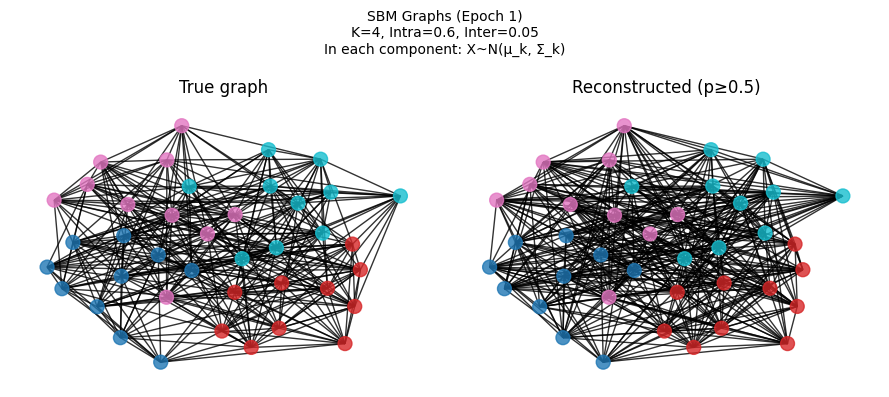

Epoch   2 | Loss: 1912.478 | Recon: 1911.506 | KL: 14.580 (β=0.067)
Epoch   3 | Loss: 1354.892 | Recon: 1353.989 | KL:  9.025 (β=0.100)
Epoch   4 | Loss: 1068.701 | Recon: 1067.762 | KL:  7.042 (β=0.133)
Epoch   5 | Loss:  952.931 | Recon: 952.077 | KL:  5.124 (β=0.167)
Epoch   6 | Loss:  905.675 | Recon: 904.756 | KL:  4.595 (β=0.200)
Epoch   7 | Loss:  889.653 | Recon: 888.711 | KL:  4.037 (β=0.233)
Epoch   8 | Loss:  885.562 | Recon: 884.734 | KL:  3.105 (β=0.267)
Epoch   9 | Loss:  886.097 | Recon: 885.322 | KL:  2.585 (β=0.300)
Epoch  10 | Loss:  883.397 | Recon: 882.621 | KL:  2.329 (β=0.333)
Epoch  11 | Loss:  884.667 | Recon: 883.802 | KL:  2.359 (β=0.367)
Epoch  12 | Loss:  882.902 | Recon: 882.088 | KL:  2.035 (β=0.400)
Epoch  13 | Loss:  884.001 | Recon: 883.202 | KL:  1.844 (β=0.433)
Epoch  14 | Loss:  883.225 | Recon: 882.399 | KL:  1.771 (β=0.467)
Epoch  15 | Loss:  885.968 | Recon: 885.191 | KL:  1.554 (β=0.500)


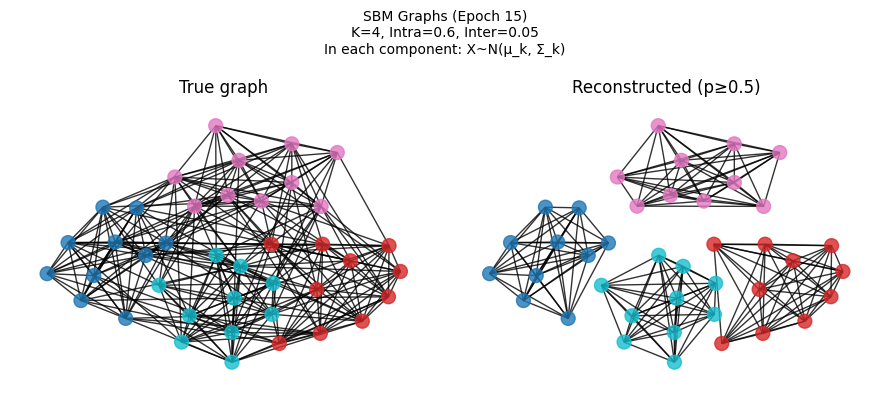

Epoch  16 | Loss:  882.866 | Recon: 882.112 | KL:  1.415 (β=0.533)
Epoch  17 | Loss:  883.322 | Recon: 882.583 | KL:  1.304 (β=0.567)
Epoch  18 | Loss:  883.950 | Recon: 883.228 | KL:  1.203 (β=0.600)
Epoch  19 | Loss:  883.417 | Recon: 882.728 | KL:  1.088 (β=0.633)
Epoch  20 | Loss:  884.251 | Recon: 883.569 | KL:  1.022 (β=0.667)
Epoch  21 | Loss:  883.867 | Recon: 883.199 | KL:  0.954 (β=0.700)
Epoch  22 | Loss:  882.601 | Recon: 881.952 | KL:  0.885 (β=0.733)
Epoch  23 | Loss:  882.524 | Recon: 881.891 | KL:  0.826 (β=0.767)
Epoch  24 | Loss:  886.603 | Recon: 885.963 | KL:  0.801 (β=0.800)
Epoch  25 | Loss:  883.910 | Recon: 883.291 | KL:  0.742 (β=0.833)
Epoch  26 | Loss:  883.036 | Recon: 882.405 | KL:  0.728 (β=0.867)
Epoch  27 | Loss:  883.144 | Recon: 882.504 | KL:  0.711 (β=0.900)
Epoch  28 | Loss:  883.563 | Recon: 882.948 | KL:  0.659 (β=0.933)
Epoch  29 | Loss:  883.076 | Recon: 882.452 | KL:  0.645 (β=0.967)
Epoch  30 | Loss:  883.383 | Recon: 882.763 | KL:  0.620 (β=1.

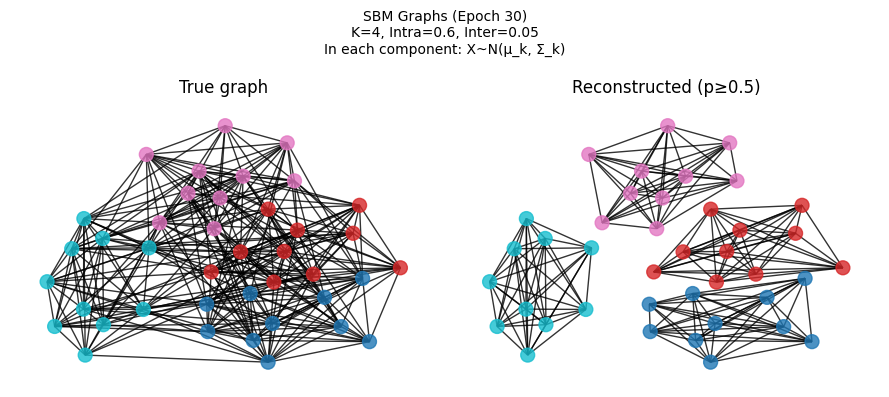

Epoch  31 | Loss:  882.096 | Recon: 881.486 | KL:  0.611 (β=1.000)
Epoch  32 | Loss:  883.229 | Recon: 882.623 | KL:  0.607 (β=1.000)
Epoch  33 | Loss:  883.260 | Recon: 882.670 | KL:  0.590 (β=1.000)
Epoch  34 | Loss:  884.106 | Recon: 883.519 | KL:  0.586 (β=1.000)
Epoch  35 | Loss:  883.565 | Recon: 882.983 | KL:  0.581 (β=1.000)
Epoch  36 | Loss:  884.561 | Recon: 883.979 | KL:  0.582 (β=1.000)
Epoch  37 | Loss:  882.909 | Recon: 882.337 | KL:  0.571 (β=1.000)
Epoch  38 | Loss:  883.393 | Recon: 882.832 | KL:  0.560 (β=1.000)
Epoch  39 | Loss:  883.503 | Recon: 882.947 | KL:  0.556 (β=1.000)
Epoch  40 | Loss:  882.181 | Recon: 881.623 | KL:  0.558 (β=1.000)
Epoch  41 | Loss:  883.366 | Recon: 882.813 | KL:  0.553 (β=1.000)
Epoch  42 | Loss:  882.444 | Recon: 881.892 | KL:  0.552 (β=1.000)
Epoch  43 | Loss:  883.704 | Recon: 883.159 | KL:  0.545 (β=1.000)
Epoch  44 | Loss:  881.774 | Recon: 881.226 | KL:  0.548 (β=1.000)
Epoch  45 | Loss:  881.720 | Recon: 881.187 | KL:  0.533 (β=1.

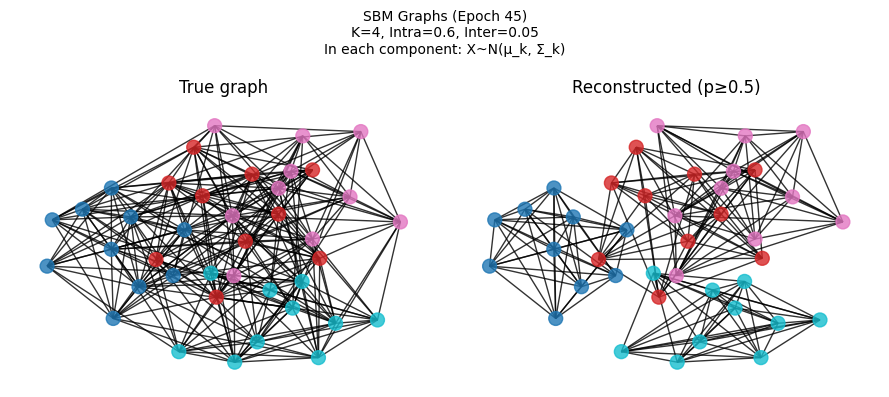

Epoch  46 | Loss:  880.740 | Recon: 880.193 | KL:  0.547 (β=1.000)
Epoch  47 | Loss:  879.857 | Recon: 879.315 | KL:  0.542 (β=1.000)
Epoch  48 | Loss:  883.008 | Recon: 882.475 | KL:  0.533 (β=1.000)
Epoch  49 | Loss:  881.698 | Recon: 881.164 | KL:  0.534 (β=1.000)
Epoch  50 | Loss:  881.836 | Recon: 881.304 | KL:  0.533 (β=1.000)
Epoch  51 | Loss:  883.384 | Recon: 882.853 | KL:  0.531 (β=1.000)
Epoch  52 | Loss:  881.021 | Recon: 880.494 | KL:  0.528 (β=1.000)
Epoch  53 | Loss:  883.811 | Recon: 883.290 | KL:  0.522 (β=1.000)
Epoch  54 | Loss:  883.776 | Recon: 883.258 | KL:  0.518 (β=1.000)
Epoch  55 | Loss:  882.317 | Recon: 881.792 | KL:  0.525 (β=1.000)
Epoch  56 | Loss:  882.249 | Recon: 881.726 | KL:  0.523 (β=1.000)
Epoch  57 | Loss:  882.978 | Recon: 882.456 | KL:  0.521 (β=1.000)
Epoch  58 | Loss:  883.754 | Recon: 883.234 | KL:  0.520 (β=1.000)
Epoch  59 | Loss:  879.962 | Recon: 879.437 | KL:  0.525 (β=1.000)
Epoch  60 | Loss:  885.010 | Recon: 884.492 | KL:  0.518 (β=1.

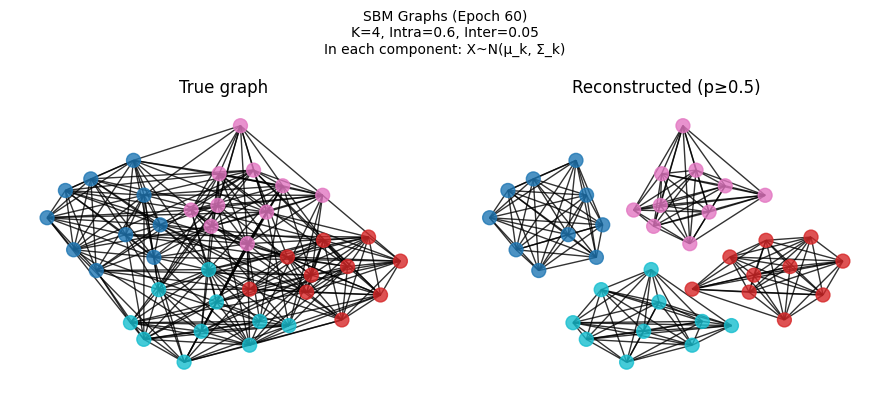

Epoch  61 | Loss:  883.833 | Recon: 883.317 | KL:  0.516 (β=1.000)
Epoch  62 | Loss:  882.224 | Recon: 881.701 | KL:  0.523 (β=1.000)
Epoch  63 | Loss:  882.927 | Recon: 882.404 | KL:  0.523 (β=1.000)
Epoch  64 | Loss:  882.803 | Recon: 882.290 | KL:  0.513 (β=1.000)
Epoch  65 | Loss:  883.785 | Recon: 883.264 | KL:  0.521 (β=1.000)
Epoch  66 | Loss:  882.393 | Recon: 881.879 | KL:  0.514 (β=1.000)
Epoch  67 | Loss:  880.595 | Recon: 880.076 | KL:  0.519 (β=1.000)
Epoch  68 | Loss:  881.294 | Recon: 880.777 | KL:  0.517 (β=1.000)
Epoch  69 | Loss:  880.900 | Recon: 880.384 | KL:  0.516 (β=1.000)
Epoch  70 | Loss:  883.261 | Recon: 882.743 | KL:  0.517 (β=1.000)
Epoch  71 | Loss:  882.969 | Recon: 882.449 | KL:  0.520 (β=1.000)
Epoch  72 | Loss:  882.218 | Recon: 881.708 | KL:  0.510 (β=1.000)
Epoch  73 | Loss:  884.513 | Recon: 883.995 | KL:  0.518 (β=1.000)
Epoch  74 | Loss:  883.041 | Recon: 882.523 | KL:  0.518 (β=1.000)
Epoch  75 | Loss:  883.285 | Recon: 882.761 | KL:  0.524 (β=1.

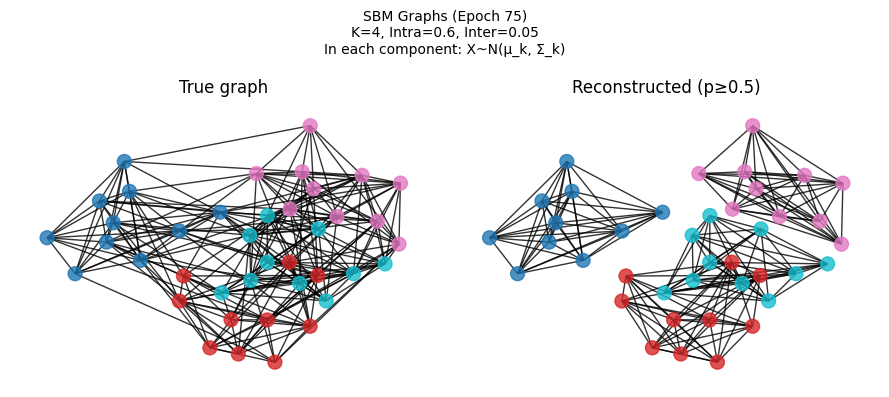

Epoch  76 | Loss:  881.318 | Recon: 880.799 | KL:  0.518 (β=1.000)
Epoch  77 | Loss:  881.690 | Recon: 881.175 | KL:  0.514 (β=1.000)
Epoch  78 | Loss:  883.494 | Recon: 882.972 | KL:  0.522 (β=1.000)
Epoch  79 | Loss:  882.055 | Recon: 881.537 | KL:  0.518 (β=1.000)
Epoch  80 | Loss:  885.602 | Recon: 885.088 | KL:  0.514 (β=1.000)


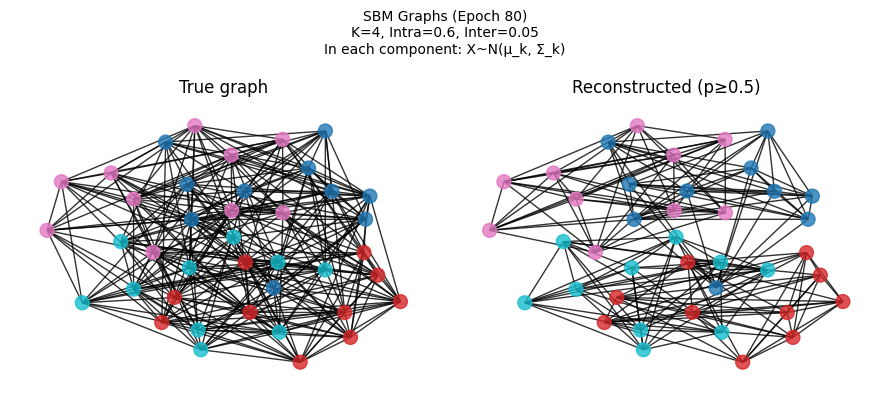

Training complete!

Testing on 6 random sequences...
----------------------------------------------------------------------
Sample 1 | Edge Accuracy: 0.7590


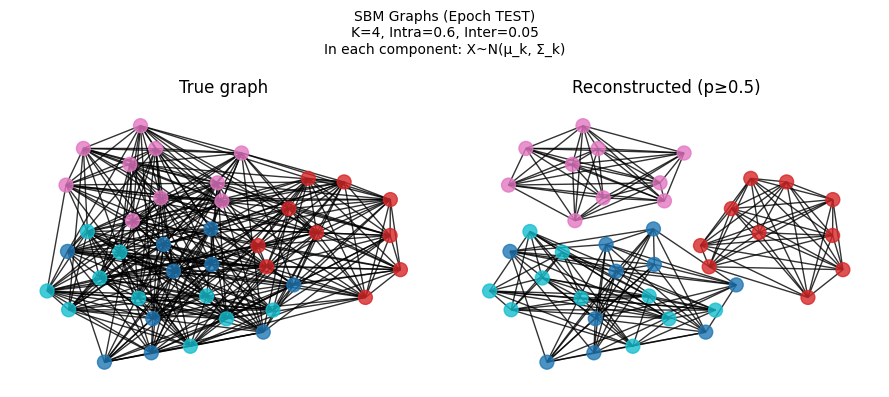

Sample 2 | Edge Accuracy: 0.8321


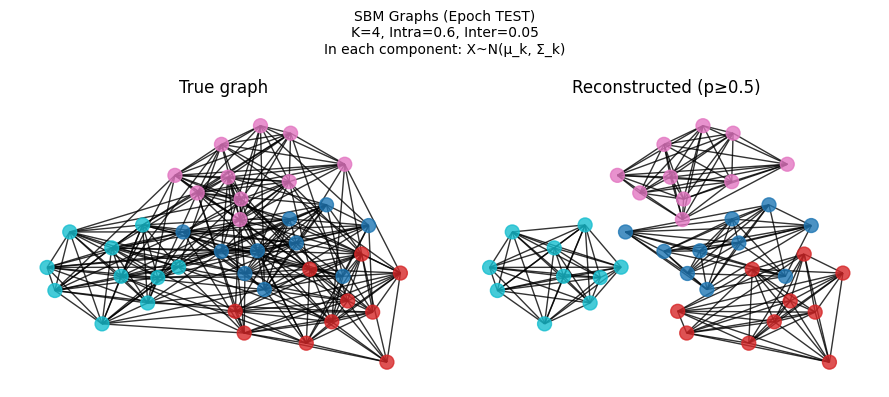

Sample 3 | Edge Accuracy: 0.8282


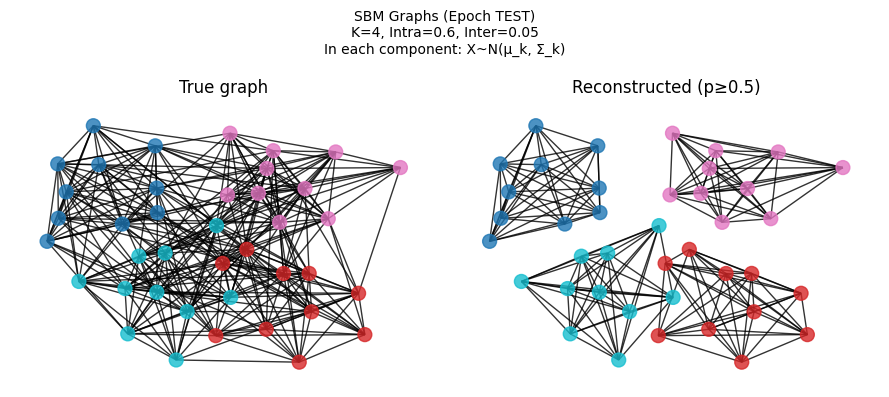

Sample 4 | Edge Accuracy: 0.8936


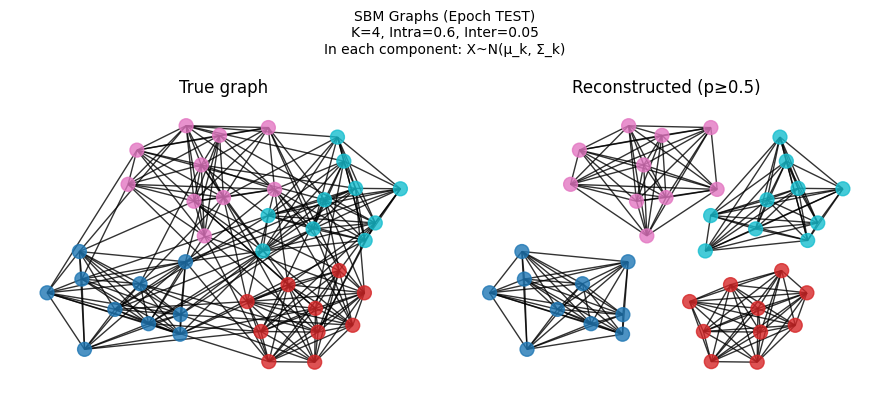

Sample 5 | Edge Accuracy: 0.7526


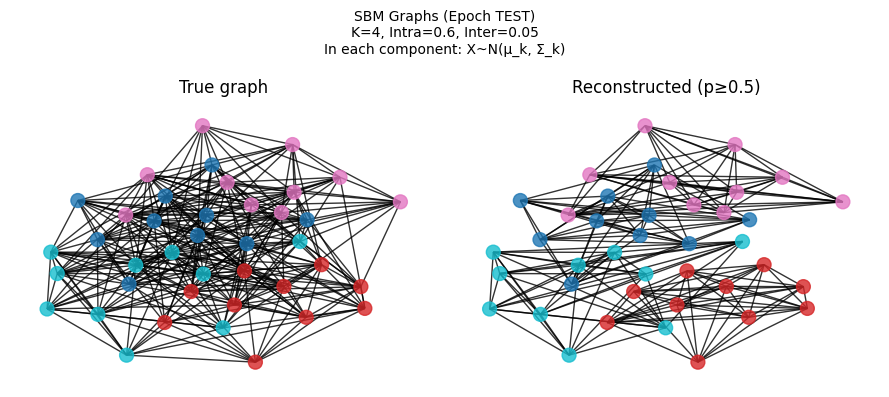

Sample 6 | Edge Accuracy: 0.7808


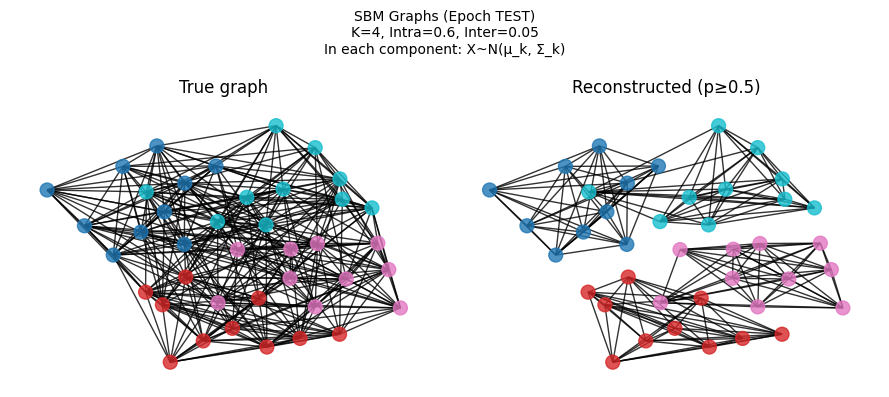


Average Edge Accuracy: 0.8077 ± 0.0492


In [21]:
# ==================== RUN EVERYTHING =====================
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Dataset
dataset = SyntheticGraphDataset(
    n_nodes=40,
    n_communities=4,
    feat_dim=8,
    T=30,
    n_seq=2000,
    p_flip=0.02
)

# 2. Model
model = TemporalGraphVAE(
    n_nodes=40,
    feat_dim=8,
    z_dim=32,
    hidden_dim=96
)

# 3. Train
trained_model = train_model(
    model=model,
    dataset=dataset,
    vis_interval=15,
    epochs=80,
    batch_size=32,
    lr=2e-3,
    device=device
)

# 4. Test
test_model(trained_model, dataset, n_samples=6)